In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA

In [ ]:
scryfall_df = pd.read_csv('./data/final-scryfall-unique-artwork.csv')

scryfall_df.head()

In [167]:
scryfall_df.columns

Index(['id', 'oracle_id', 'name', 'set_id', 'set', 'set_name', 'artist_ids',
       'artist', 'released_at', 'type_line', 'keywords', 'rarity',
       'color_identity', 'cmc', 'power', 'toughness', 'edhrec_rank', 'type',
       'subtype', 'legality_commander', 'legality_standard', 'price_usd',
       'image_uri_normal', 'image_uri_art_crop'],
      dtype='str')

In [ ]:
final_df = scryfall_df.copy()

final_df['rarity'] = final_df['rarity'].map({'common':0, 'special':0.5, 'uncommon':1, 'rare':2, 'mythic':3})
final_df['legality_commander'] = final_df['legality_commander'].map({'legal': 1, 'banned': 0.5, 'not_legal': 0})
final_df['legality_standard'] = final_df['legality_standard'].map({'legal': 1, 'banned': 0.5, 'not_legal': 0})
final_df = final_df[(final_df['toughness'].str.isnumeric()) & (final_df['power'].str.isnumeric())]

In [111]:
creature_df = final_df[final_df['type'] == 'Creature']
creature_df = creature_df[creature_df['edhrec_rank'].notna()]
creature_df = creature_df[['power', 'toughness', 'edhrec_rank', 'price_usd', 'legality_commander', 'rarity']]

creature_df.isna().sum()

power                 0
toughness             0
edhrec_rank           0
price_usd             0
legality_commander    0
rarity                0
dtype: int64

In [143]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(creature_df)

X_normalized = normalize(X_scaled)
X_normalized = pd.DataFrame(X_normalized)

X_normalized.head()

,0,1,2,3,4,5
0,0.321937,0.201834,-0.917179,-0.052224,0.067326,0.084518
1,-0.268962,-0.355222,0.228817,-0.043058,0.051655,-0.862901
2,-0.637899,-0.288684,0.122266,-0.035479,0.041979,-0.701268
3,-0.293174,-0.943193,0.118752,-0.046562,0.056305,0.070683
4,0.177603,-0.622179,0.440506,-0.031022,0.037142,-0.620454


In [180]:
pca = PCA(n_components=2)
X_principal = pca.fit_transform(creature_df)
X_principal = pd.DataFrame(X_principal)
X_principal.columns = ['P1', 'P2']

print(X_principal.head())

            P1        P2
0 -7443.597397 -6.411631
1  2420.402463 -4.481082
2  1591.402503 -4.743053
3  1152.402450 -4.734175
4  6480.402358 -3.552057


In [192]:
db = DBSCAN(eps=1, min_samples=6, metric='euclidean', metric_params=None, 
            algorithm='auto', leaf_size=30, p=None, n_jobs=None).fit(X_principal)

labels = db.labels_
label_count = np.unique_counts(labels)
print(label_count.values, label_count.counts)

[-1  0  1  2] [14098     8     9     6]


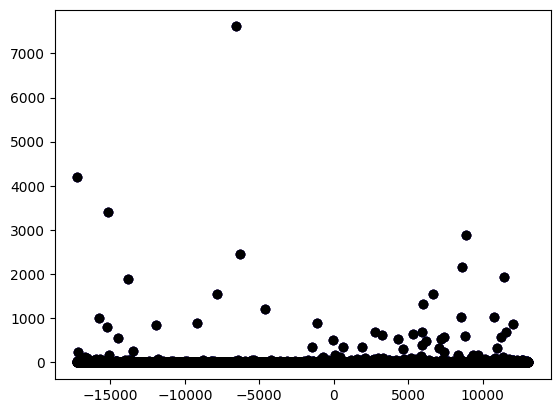

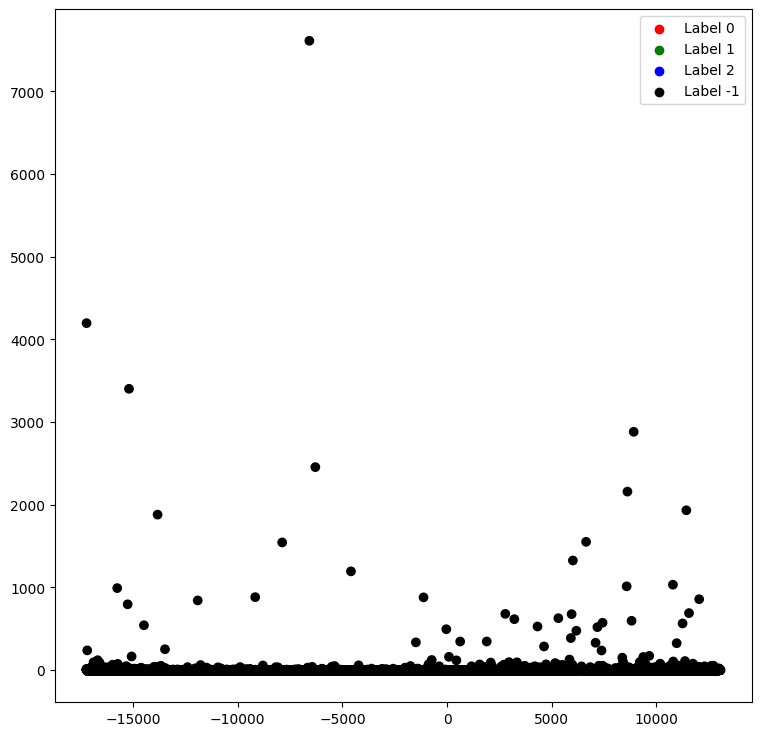

In [183]:
colours = {}
colours[0] = 'r'
colours[1] = 'g'
colours[2] = 'b'
colours[-1] = 'k'

# Building the colour vector for each data point
cvec = [colours[label] for label in labels]

# For the construction of the legend of the plot
r = plt.scatter(X_principal['P1'], X_principal['P2'], color ='r');
g = plt.scatter(X_principal['P1'], X_principal['P2'], color ='g');
b = plt.scatter(X_principal['P1'], X_principal['P2'], color ='b');
k = plt.scatter(X_principal['P1'], X_principal['P2'], color ='k');

# Plotting P1 on the X-Axis and P2 on the Y-Axis 
# according to the colour vector defined
plt.figure(figsize =(9, 9))
plt.scatter(X_principal['P1'], X_principal['P2'], c = cvec)

# Building the legend
plt.legend((r, g, b, k), ('Label 0', 'Label 1', 'Label 2', 'Label -1'))

plt.show()

In [195]:
sil_score = silhouette_score(X_principal, labels)
print("Silhouette Coefficient: %0.2f" % sil_score)
db_score = davies_bouldin_score(X_principal, labels)
print("Davies Bouldin Score: %0.2f" % db_score)
ch_score = calinski_harabasz_score(X_principal, labels)
print("Calinski Harabasz Score: %0.2f" % ch_score)

Silhouette Coefficient: -0.57
Davies Bouldin Score: 0.97
Calinski Harabasz Score: 10.90
